# Direct Wind Magnet Layout:

## Non-UI Version:

Radii of Condutor Layers: [2.17, 2.44, 2.71]
Harmonics [n=0,dipole, n=1,quad, n=2,sext, n=3,oct, n=4,deca]: [-1.830157 -0.000000 169.272124 0.000000 -1.229381]
Relative to main: [-0.010812 -0.000000 1.000000 0.000000 -0.007263]
Harmonics in 10^4 units: [-108.119227 -0.000000 10000.000000 0.000000 -72.627492]


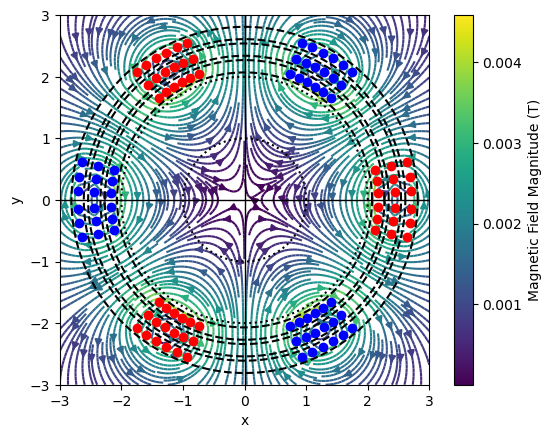

CPU times: total: 14.2 s
Wall time: 14.4 s


In [37]:
%%time
import numpy as np
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from scipy.stats import norm
import panel as pn
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
# Sets the floats to round instead of going into scientific notation
np.set_printoptions(suppress=True, formatter={'float_kind':'{:0.6f}'.format})

# =============== Function definitions ===============

# Need to be able to do this for mutiple groups, so different angular bounds at same rad
def plotter(lower, upper, rad, point_num): # Need to find a way to not have them evenly dispersed through the radius, need them side-by-side
    # Iterate through lower and upper angle bounds, with some dphi that determines the spacing
    phi_list = np.linspace(np.deg2rad(lower), np.deg2rad(upper), point_num) # Enter in degrees
    x = rad*np.cos(phi_list)
    y = rad*np.sin(phi_list)
    return x, y

def circ_plot(rad, color='k--'):
    circ = np.linspace(0, 2*np.pi, 500)
    x = rad * np.cos(circ)
    y = rad * np.sin(circ)
    plt.plot(x, y, color, zorder=1)

# The field defined in terms of the harmonics
def B_harm(x, y, x_a, y_a, I):
    # Position of the conductor
    a = np.hypot(x_a, y_a)
    
    # Position of field measurement
    r = np.hypot(x, y)

    # Angle between a and y=0
    phi = np.arctan2(y_a, x_a)
    # Angle between r and y=0
    theta = np.arctan2(y, x)

    # Angle between r and a
    ang = phi - theta

    # Replace r=0 with r=1e-20 to avoid divsion by zero
    r = np.where(r == 0, 1e-10, r)

    # Now we compute the field for both cases, adding up harmonics until the n_max harmonic is calculated and added

    # Case for r < a:
    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max+1)], axis=0)
    B_theta_in = (-1)*((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max+1)], axis=0)
    
    # Case for r > a:
    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max+1)], axis=0)
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max+1)], axis=0)

    # Use np.where to select the correct field values to return
    # np.where(cond., x, y) -> If true, takes x; if false, takes y
    B_r = np.where(r > a, B_r_out, B_r_in)
    B_theta = np.where(r > a, B_theta_out, B_theta_in)

    # Convert to cartesian coordinates (notably using the angle theta, not ang)
    B_x = B_r * np.cos(theta) - B_theta * np.sin(theta)
    B_y = B_r * np.sin(theta) + B_theta * np.cos(theta)

    return B_x, B_y

# To calculate the individual harmonic at ref_rad (R0) due to a conductor with current I at position (a, phi)
# Poles go by (n+1), so n=2 -> 3phi -> Sextupole
# 0 = Dipole, 1=Quadrupole, 2=Sextupole, etc.
# For a dipole, even harmonics are not allowed, so here we just look at odd constributions
def Harmonic(R0, a, phi, n, I_wire):
    return (mu0*I_wire/2*np.pi) * (10**4) * ((R0 / a)**n) * np.cos((n + 1) * phi)


# =============== User defined varaiables ===============

# Max n values for field calculation
n_max = 10
# Radius of aperture
aper_rad = 2 
# Min angle from the x-axis for the first block in each layer
min_ang = 20
# Radial spacing
dr = 0.1 
# Thickness of spacing between layers
t = 0.07 
# Reference radius
ref_rad = 1
# Current magnitude
I0 = 500

# Type of magnet: 1=dipole, 2=quadrupole, 3=sextupole
mag_type = 3

# Set it to only show the surface plot for the field strength along the body of the magnet
surf_plot = False

# To set to either show all quadrants or only the first quadrant here:
all_quads = True

# =============== Defined variables ===============
# Vacuum permeability
mu0 = 4 * np.pi * 1e-7 
# Radius of the first layer, based on aperture radius
init_rad = aper_rad + dr 

# Right now, points are distributed uniformly over the angular region, thus, angular spacing between points is not controlled by the user
# spacing = [ [], [], [] ]
# This contains the dphi for each block
# For n blocks we have n+1 spaces to worry about

"""
TO-DO:
Need to make a function that creates a list of angles based on spacing list
Spacing does not have to be the same for each layer
Each spacing value is a delta phi really
Based on the min angle set above
"""
num_of_layers = 3
spacing = []
#spacing = [[] for i in range(n)] # -> makes a list of [ [], [], [], ..., [] ]

# These are just examples for each of the magnet types
if mag_type == 1:
    # Dipole example:
    layers = [ 
                    [ [10], [ (5, 80) ] ], # Layer 1
                    [ [10], [ (5, 80) ] ], # Layer 2
                    [ [10], [ (5, 80) ] ] # Layer 3
             ]
elif mag_type == 2:
    # Quadrupole example:
    layers = [ 
                    [ [5, 5], [ (3, 20), (70, 87) ] ], # Layer 1
                    [ [5, 5], [ (3, 20), (70, 87) ] ], # Layer 2
                    [ [5, 5], [ (3, 20), (70, 87) ] ] # Layer 3
             ]
elif mag_type == 3:
    # Sextupole example:
    layers = [ 
                    [ [3, 6], [ (3, 13), (50, 70)] ], # Layer 1
                    [ [3, 6], [ (3, 13), (50, 70)] ], # Layer 2
                    [ [3, 6], [ (3, 13), (50, 70)] ] # Layer 3
             ]

# =============== Geomerty calculations ===============

# Arrays of the x and y values per layer
x_quad1 = []
y_quad1 = []

# A list of radii to plot based on the layer spacing:
rads = []
# Loops over each layer
for i, layer in enumerate(layers): # Goes from 1-3
    # Radii at which points are plotted, depends only on the layer we are on
    rads.append(init_rad+(2*i*dr) + (i+1)*t) 
    # Loops over the second list in each layer
    for j, ang_list in enumerate(layer[1]):
        # Calulates the x and y values of each conductor for that blocks given angles
        # Accounts for the spacing between the layers, layer[0][j] is the number of conductors
        # x and y are the give an array of coordinates for each conductor in the block
        x, y = plotter(ang_list[0], ang_list[1], init_rad+(2*i*dr) + (i+1)*t, layer[0][j])  
        x_quad1.append(x)
        y_quad1.append(y)


# Concatenation puts them all into just one list
# Concatenated list is still in block order
x_totq1 = np.concatenate(x_quad1)
y_totq1 = np.concatenate(y_quad1)

# Reflect values to each quadrant:
# Q2 
x_totq2 = -1*x_totq1
y_totq2 = y_totq1
# Q3
x_totq3 = -1*x_totq1
y_totq3 = -1*y_totq1
# Q4
x_totq4 = x_totq1
y_totq4 = -1*y_totq1
# Concatenate all these lists to make a total list of x and y values
x_tot = np.concatenate( (x_totq1, x_totq2, x_totq3, x_totq4) )
y_tot = np.concatenate( (y_totq1, y_totq2, y_totq3, y_totq4) )


print(f"Radii of Condutor Layers: {[round(r, 2) for r in rads]}")

# Shows all quadrants or only 1st quadrant based on setting above:
if all_quads:
    # Bounds for all four quadrants:
    bounds =  [ [-3, 3], [-3, 3] ]
elif not all_quads:
    # Bounds for first quadrant only:
    bounds =  [ [0, 3], [0, 3] ]


# =============== Magnetic Field & Harmonic calculations ===============

# Grid setup (for plotting the field)
# The field is always calculated everywhere in this region
x = np.linspace(bounds[0][0], bounds[0][1], 250)
y = np.linspace(bounds[1][0], bounds[1][1], 250)
X, Y = np.meshgrid(x, y)

Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

# Here we caluclate the harmonic components for each n in n_list witin the given ref_rad
n_list = [0, 1, 2, 3, 4]  # dipole, quadrupole, sextupole, octupole, deacpole, etc.

 # From the magtype definition, sets main field to whatever the magnet type is set to
B_main_index = mag_type - 1

# Initializing harmonics array
# Need to intialize to add to the initial zero, otherwise throws an error
harms = np.zeros(len(n_list)) 

# Assigns currents based on magnet type
# Uses cos theta for dipole to change sign
# Uses cos 2theta for quadrupole to change sign
# Uses cos 3theta for sextupole to change sign
# etc.
for xa, ya in zip(x_tot, y_tot):
    phi = np.arctan2(ya, xa)
    a   = np.hypot(xa, ya)
    # Check the sign of cosine to determine the sign of the current
    if np.cos(mag_type*phi) >= 0:
        I = I0
    else:
        I=-I0

    Bx, By = B_harm(X, Y, xa, ya, I)
    if surf_plot == True:
        pass
    else:
        plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"))

    Bx_total += Bx
    By_total += By

    # Calculates the harmonic contribution due to the current conductor
    for j, n_val in enumerate(n_list):
        harms[j] += Harmonic(ref_rad, a, phi, n_val, I)  # Sign of current matters
    
# Total B-field magnitudes are computed
B_mag = np.hypot(Bx_total, By_total)

print("Harmonics [n=0,dipole, n=1,quad, n=2,sext, n=3,oct, n=4,deca]:", harms)
print("Relative to main:", harms / (harms[B_main_index] if harms[B_main_index] != 0 else 1))

# convert to 10^4 units relative to main multipole:
B_main = harms[B_main_index]  # for dipole magnet, n=0 is main
units = (harms / B_main) * 1e4
print("Harmonics in 10^4 units:", units)



# =============== Magnetic Field & Harmonic calculations ===============

if surf_plot == True:
    fig, ax = plt.subplots(figsize=(6,6))
    mask = (X**2 + Y**2 >= aper_rad**2) & (X**2 + Y**2 <= (rads[-1]+dr)**2)
    B_mag_masked = np.where(mask, B_mag, np.nan)
    
    # Create the surface plot (can switch to B_mag_masked)
    pcm = ax.pcolormesh(X, Y, B_mag_masked, shading='auto', cmap='viridis')
    fig.colorbar(pcm, ax=ax, label='Magnetic Field Magnitude (T)')
else:
    # Plots the magnetic field lines
    strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', density=3, zorder=0)
    cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')

# Plots circles around \pm dr awway from where the conductors are (offset by t as done above)
for rad in rads:
    circ_plot(rad+dr)
    circ_plot(rad-dr)

# Aperture Radius
circ_plot(aper_rad, color='k:')
# Reference Radius
circ_plot(ref_rad, color='k:')

plt.xlim(bounds[0][0], bounds[0][1])
plt.ylim(bounds[1][0], bounds[1][1])
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, color='black', linewidth=1, zorder=1)
plt.axvline(0, color='black', linewidth=1, zorder=1)
plt.gca().set_aspect('equal')
plt.show()

## Panel Version:

In [33]:
%%time
import numpy as np
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from scipy.stats import norm
import panel as pn
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

pn.extension()

# Make floats print nicely
np.set_printoptions(suppress=True, formatter={'float_kind':'{:0.6f}'.format})

# ========================= Your function definitions (unchanged) =========================

def plotter(lower, upper, rad, point_num):
    """Return (x,y) conductor coordinates along an arc."""
    phi_list = np.linspace(np.deg2rad(lower), np.deg2rad(upper), point_num)  # degrees in, radians used
    x = rad*np.cos(phi_list)
    y = rad*np.sin(phi_list)
    return x, y

def circ_plot(ax, rad, color='k--'):
    circ = np.linspace(0, 2*np.pi, 500)
    x = rad * np.cos(circ)
    y = rad * np.sin(circ)
    ax.plot(x, y, color, zorder=1)

def B_harm(x, y, x_a, y_a, I, mu0, n_max):
    a = np.hypot(x_a, y_a)
    r = np.hypot(x, y)

    phi = np.arctan2(y_a, x_a)
    theta = np.arctan2(y, x)

    ang = phi - theta

    r = np.where(r == 0, 1e-10, r)

    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max+1)], axis=0)
    B_theta_in = (-1)*((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max+1)], axis=0)

    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max+1)], axis=0)
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max+1)], axis=0)

    B_r = np.where(r > a, B_r_out, B_r_in)
    B_theta = np.where(r > a, B_theta_out, B_theta_in)

    B_x = B_r * np.cos(theta) - B_theta * np.sin(theta)
    B_y = B_r * np.sin(theta) + B_theta * np.cos(theta)
    return B_x, B_y

def Harmonic(R0, a, phi, n, I_wire, mu0):
    # (n+1) multipole index; returns contribution in Gauss units via *1e4 factor
    return (mu0*I_wire/2*np.pi) * (10**4) * ((R0 / a)**n) * np.cos((n + 1) * phi)

# ========================= Widgets =========================

# Scalars
w_n_max    = pn.widgets.IntSlider(name="Max n values (n_max)", value=10, start=1, end=50, step=1)
w_aper_rad = pn.widgets.FloatSlider(name="Aperture radius (aper_rad)", value=2.0, start=0.1, end=5.0, step=0.01)
w_min_ang  = pn.widgets.FloatSlider(name="Min angle from x-axis for first block (deg)", value=20.0, start=0.0, end=89.0, step=1.0)
w_dr       = pn.widgets.FloatSlider(name="Radial spacing (dr)", value=0.1, start=0.01, end=1.0, step=0.01)
w_t        = pn.widgets.FloatSlider(name="Thickness between layers (t)", value=0.07, start=0.0, end=0.5, step=0.005)
w_ref_rad  = pn.widgets.FloatSlider(name="Reference radius (ref_rad)", value=1.0, start=0.05, end=3.0, step=0.01)
w_I0       = pn.widgets.FloatSlider(name="Current magnitude (I0)", value=500.0, start=10.0, end=5000.0, step=10.0)

w_mag_type = pn.widgets.Select(name="Magnet type", options={"Dipole":1, "Quadrupole":2, "Sextupole":3}, value=1)
w_surf_plot= pn.widgets.Checkbox(name="Show surface plot only", value=False)
w_all_quads= pn.widgets.Checkbox(name="Show all quadrants", value=True)

# Dynamic LAYERS editor
w_num_layers = pn.widgets.IntSlider(name="Number of layers", value=3, start=1, end=8)

layers_editor = pn.Column(sizing_mode="stretch_width")
# Keep references to per-block widgets so we can read them on Run
# Structure: layer_widgets[i] = list of dicts { 'num': IntInput, 'ang': RangeSlider }
layer_widgets = []

def make_block_row(layer_idx, block_idx):
    num = pn.widgets.IntInput(name=f"Layer {layer_idx+1} • Block {block_idx+1} • #conductors",
                              value=5, start=1, end=100)
    ang = pn.widgets.RangeSlider(name="Angle range (deg)",
                                 start=0, end=180, step=0.5, value=(max(0, w_min_ang.value-5), max(5, w_min_ang.value+60)))
    return {'num': num, 'ang': ang}

def rebuild_layers_editor(event=None):
    layers_editor.clear()
    layer_widgets.clear()
    for i in range(w_num_layers.value):
        # Number of blocks in this layer
        w_blocks = pn.widgets.IntInput(name=f"Layer {i+1}: number of blocks", value=1, start=1, end=12)
        blocks_container = pn.Column()
        lw = []  # widgets for this layer

        def _rebuild_blocks(ev=None, _i=i, _lw=lw, _bc=blocks_container):
            _bc.clear()
            # Ensure at least 1
            nb = max(1, w_blocks.value)
            _lw[:] = [make_block_row(_i, b) for b in range(nb)]
            for bdict in _lw:
                _bc.append(pn.Row(bdict['num'], bdict['ang']))

        w_blocks.param.watch(_rebuild_blocks, 'value')
        _rebuild_blocks()  # initial
        layer_widgets.append(lw)
        layers_editor.append(
            pn.Card(pn.Column(w_blocks, blocks_container),
                    title=f"Layer {i+1}", collapsible=True, collapsed=False)
        )

rebuild_layers_editor()
w_num_layers.param.watch(rebuild_layers_editor, 'value')

# ========================= Output panes & button =========================

run_button = pn.widgets.Button(name="Plot results", button_type="primary")
status_md  = pn.pane.Markdown("")
harmonics_md = pn.pane.Markdown("")
fig_pane   = pn.pane.Matplotlib(height=650, tight=True)

# ========================= Core runner =========================

def build_layers_from_widgets():
    """
    Build `layers` in the exact structure your code expects:
    layers = [
       [ [n_block1, n_block2, ...], [ (low1,up1), (low2,up2), ... ] ],  # Layer 1
       ...
    ]
    """
    layers = []
    for i, layer in enumerate(layer_widgets):
        n_list = []
        ang_list = []
        for bdict in layer:
            n_val = int(bdict['num'].value)
            low, up = bdict['ang'].value
            # Sanity clamp + ensure low<up
            low = float(low); up = float(up)
            if up <= low:
                up = low + 1e-3
            n_list.append(n_val)
            ang_list.append( (low, up) )
        layers.append([n_list, ang_list])
    return layers

def run_and_plot(event=None):
    status_md.object = "Running…"

    # =============== Read current widget values ===============
    n_max     = int(w_n_max.value)
    aper_rad  = float(w_aper_rad.value)
    min_ang   = float(w_min_ang.value)  # (not directly used yet; you can wire it to default sliders)
    dr        = float(w_dr.value)
    t         = float(w_t.value)
    ref_rad   = float(w_ref_rad.value)
    I0        = float(w_I0.value)
    mag_type  = int(w_mag_type.value)
    surf_plot = bool(w_surf_plot.value)
    all_quads = bool(w_all_quads.value)

    mu0 = 4 * np.pi * 1e-7
    init_rad = aper_rad + dr

    # Build layers from GUI (examples are DISABLED)
    layers = build_layers_from_widgets()
    # # Examples (DISABLED as requested)
    # if mag_type == 1:
    #     layers = [[[10],[(5,80)]], [[10],[(5,80)]], [[10],[(5,80)]]]
    # elif mag_type == 2:
    #     layers = [[[5,5],[(3,20),(70,87)]], [[5,5],[(3,20),(70,87)]], [[5,5],[(3,20),(70,87)]]]
    # elif mag_type == 3:
    #     layers = [[[3,6],[(3,13),(50,70)]], [[3,6],[(3,13),(50,70)]], [[3,6],[(3,13),(50,70)]]]

    # =============== Geometry calculations ===============
    x_quad1, y_quad1 = [], []
    rads = []

    for i, layer in enumerate(layers):
        r_layer = init_rad + (2*i*dr) + (i+1)*t
        rads.append(r_layer)
        for j, ang_pair in enumerate(layer[1]):
            lower, upper = ang_pair
            x, y = plotter(lower, upper, r_layer, int(layer[0][j]))
            x_quad1.append(x)
            y_quad1.append(y)

    if len(x_quad1)==0:
        status_md.object = "**No conductors specified.** Add at least one block."
        return

    x_totq1 = np.concatenate(x_quad1)
    y_totq1 = np.concatenate(y_quad1)

    # Reflect to all quadrants (matching your original behavior)
    x_totq2 = -1*x_totq1; y_totq2 =  y_totq1
    x_totq3 = -1*x_totq1; y_totq3 = -1*y_totq1
    x_totq4 =  x_totq1;   y_totq4 = -1*y_totq1

    x_tot = np.concatenate((x_totq1, x_totq2, x_totq3, x_totq4))
    y_tot = np.concatenate((y_totq1, y_totq2, y_totq3, y_totq4))

    # Bounds for plotting window
    if all_quads:
        bounds = [[-3,3],[-3,3]]
    else:
        bounds = [[0,3],[0,3]]

    # =============== Field & harmonics ===============
    x = np.linspace(bounds[0][0], bounds[0][1], 250)
    y = np.linspace(bounds[1][0], bounds[1][1], 250)
    X, Y = np.meshgrid(x, y)
    Bx_total = np.zeros_like(X)
    By_total = np.zeros_like(Y)

    n_list = [0, 1, 2, 3, 4]   # dipole, quad, sext, oct, deca
    B_main_index = mag_type - 1
    harms = np.zeros(len(n_list))

    # Create fresh figure
    fig, ax = plt.subplots(figsize=(6,6))

    for xa, ya in zip(x_tot, y_tot):
        phi = np.arctan2(ya, xa)
        a   = np.hypot(xa, ya)

        # Current sign by cosine symmetry
        I = I0 if np.cos(mag_type*phi) >= 0 else -I0

        Bx, By = B_harm(X, Y, xa, ya, I, mu0, n_max)
        if not surf_plot:
            ax.scatter(xa, ya, c=("red" if I >= 0 else "blue"), s=12, zorder=3)

        Bx_total += Bx
        By_total += By

        for j, n_val in enumerate(n_list):
            harms[j] += Harmonic(ref_rad, a, phi, n_val, I, mu0)

    B_mag = np.hypot(Bx_total, By_total)

    # Harmonics readout
    main_val = harms[B_main_index] if harms[B_main_index] != 0 else 1.0
    rel = harms / (main_val if main_val != 0 else 1)
    units = (harms / (harms[B_main_index] if harms[B_main_index]!=0 else 1)) * 1e4

    harmonics_md.object = (
        "### Harmonics\n"
        f"**[n=0,dipole; n=1,quad; n=2,sext; n=3,oct; n=4,deca]**\n\n"
        f"Raw: `{np.round(harms,3)}`\n\n"
        f"Relative to main: `{np.round(rel,6)}`\n\n"
        f"In 10^4 units: `{np.round(units,3)}`\n"
    )

    # Plotting
    if surf_plot:
        mask = (X**2 + Y**2 >= aper_rad**2) & (X**2 + Y**2 <= (rads[-1]+w_dr.value)**2)
        B_mag_masked = np.where(mask, B_mag, np.nan)
        pcm = ax.pcolormesh(X, Y, B_mag_masked, shading='auto', cmap='viridis')
        fig.colorbar(pcm, ax=ax, label='Magnetic Field Magnitude (T)')
    else:
        strm = ax.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', density=3, zorder=0)
        cbar = fig.colorbar(strm.lines, ax=ax, label='Magnetic Field Magnitude (T)')

    # Radii overlays
    for rad in rads:
        circ_plot(ax, rad+w_dr.value)
        circ_plot(ax, rad-w_dr.value)

    # Aperture & reference radii
    circ_plot(ax, aper_rad, color='k:')
    circ_plot(ax, ref_rad, color='k:')

    ax.set_xlim(bounds[0][0], bounds[0][1])
    ax.set_ylim(bounds[1][0], bounds[1][1])
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.axhline(0, color='black', linewidth=1, zorder=1)
    ax.axvline(0, color='black', linewidth=1, zorder=1)
    ax.set_aspect('equal')

    fig_pane.object = fig
    status_md.object = (
        f"**Done.** Layers radii = `{[round(r,3) for r in rads]}` • "
        f"mag_type = {['Dipole','Quadrupole','Sextupole'][mag_type-1]} • "
        f"surf_plot = {surf_plot} • all_quads = {all_quads}"
    )

run_button.on_click(run_and_plot)

# ========================= Layout =========================

left_col = pn.WidgetBox(
    "### Global parameters",
    w_n_max, w_aper_rad, w_min_ang, w_dr, w_t, w_ref_rad, w_I0,
    w_mag_type, w_surf_plot, w_all_quads,
    "### Layers",
    w_num_layers,
    sizing_mode="stretch_width"
)

layout = pn.Column(
    pn.Row(left_col, layers_editor, sizing_mode="stretch_width"),
    pn.Row(run_button, sizing_mode="stretch_width"),
    status_md,
    pn.Row(fig_pane),
    harmonics_md,
    sizing_mode="stretch_width"
)

layout.servable()
layout  # If running in a notebook, this will display inline


CPU times: total: 203 ms
Wall time: 195 ms


Column(sizing_mode='stretch_width')
    [0] Row(sizing_mode='stretch_width')
        [0] WidgetBox(sizing_mode='stretch_width')
            [0] Markdown(str)
            [1] IntSlider(end=50, name='Max n values (n_max)', start=1, value=10)
            [2] FloatSlider(end=5.0, name='Aperture radius (..., start=0.1, step=0.01, value=2.0)
            [3] FloatSlider(end=89.0, name='Min angle from x..., step=1.0, value=20.0)
            [4] FloatSlider(name='Radial spacing (dr)', start=0.01, step=0.01, value=0.1)
            [5] FloatSlider(end=0.5, name='Thickness between l..., step=0.005, value=0.07)
            [6] FloatSlider(end=3.0, name='Reference radius (..., start=0.05, step=0.01, value=1.0)
            [7] FloatSlider(end=5000.0, name='Current magnitude (I0)', start=10.0, step=10.0, value=500.0)
            [8] Select(name='Magnet type', options={'Dipole': 1, ...}, value=1)
            [9] Checkbox(name='Show surface plot only')
            [10] Checkbox(name='Show all quadrants', value=True)
            [11] Markdown(str)
            [12] IntSlider(end=8, name='Number of layers', start=1, value=3)
        [1] Column(sizing_mode='stretch_width')
            [0] Card(title='Layer 1')
                [0] Column
                    [0] IntInput(end=12, name='Layer 1: number o..., start=1, value=1)
                    [1] Column
                        [0] Row
                            [0] IntInput(end=100, name='Layer 1 • Block 1..., start=1, value=5)
                            [1] RangeSlider(end=180, name='Angle range (deg)', step=0.5, value=(15.0, 80.0), value_end=80.0, value_start=15.0)
            [1] Card(title='Layer 2')
                [0] Column
                    [0] IntInput(end=12, name='Layer 2: number o..., start=1, value=1)
                    [1] Column
                        [0] Row
                            [0] IntInput(end=100, name='Layer 2 • Block 1..., start=1, value=5)
                            [1] RangeSlider(end=180, name='Angle range (deg)', step=0.5, value=(15.0, 80.0), value_end=80.0, value_start=15.0)
            [2] Card(title='Layer 3')
                [0] Column
                    [0] IntInput(end=12, name='Layer 3: number o..., start=1, value=1)
                    [1] Column
                        [0] Row
                            [0] IntInput(end=100, name='Layer 3 • Block 1..., start=1, value=5)
                            [1] RangeSlider(end=180, name='Angle range (deg)', step=0.5, value=(15.0, 80.0), value_end=80.0, value_start=15.0)
    [1] Row(sizing_mode='stretch_width')
        [0] Button(button_type='primary', name='Plot results')
    [2] Markdown(str)
    [3] Row
        [0] Matplotlib(None, height=650, tight=True)
    [4] Markdown(str)